In [23]:
import pandas as pd
import numpy as np
from os import getcwd, listdir, path
import matplotlib.pyplot as plt
import sys
import ast
from glob import glob

import fitness.data_generating_process as dgp
import fitness.soga_fitness_SCM as soga_fitness_SCM
import fitness.interventions as interventions

In [24]:
# Read all pareto_fitness.txt files under results/causal_skills_tests and build aggregated stats
ex_name = 'common_cause_fixed_interventions'
program = 'common_cause'
base_dir = path.join('..', 'results', ex_name)
pattern = path.join(base_dir, '**', 'pareto_fitness.txt')
files = glob(pattern, recursive=True)

records = []
for fp in files:
    df = pd.read_csv(fp, sep='\t', header=None, names=['generation', 'fitness_class'])
    df[['fitness', 'class']] = pd.DataFrame(
        df['fitness_class'].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else x
        ).tolist(),
        index=df.index,
    )
    df['run'] = path.basename(path.dirname(fp))
    records.append(df[['generation', 'fitness', 'class', 'run']])
    # drop duplicate entries
    records[-1] = records[-1].drop_duplicates(subset=['generation', 'fitness', 'class', 'run'])

if records:
    pareto_fitness = pd.concat(records, ignore_index=True)
else:
    pareto_fitness = pd.DataFrame(columns=['generation', 'fitness', 'class', 'run'])

# Aggregate mean/std per generation and class and median and interquartile range
pareto_stats = (
    pareto_fitness
    .groupby(['generation', 'class'])['fitness']
    .agg(['mean', 'std', 'count', np.median, lambda x: np.percentile(x, 25), lambda x: np.percentile(x, 75)])
    .reset_index()
    .rename(columns={'mean': 'fitness_mean', 'std': 'fitness_std', 'count': 'n', 'median': 'fitness_median', '<lambda_0>': 'fitness_q1', '<lambda_1>': 'fitness_q3'})
)
pareto_stats['fitness_std'] = pareto_stats['fitness_std'].fillna(0)

print(f"Found {len(files)} pareto_fitness.txt files")
print(pareto_stats.head())
print(f"\nGenerations: {pareto_stats['generation'].min() if not pareto_stats.empty else 'NA'} to {pareto_stats['generation'].max() if not pareto_stats.empty else 'NA'}")

# Save aggregated stats to a new file csv named ex_name + '_pareto_stats.csv' and
# saved in ../results/synhesis
output_fp = path.join('..', 'results', 'synthesis', f'{ex_name}_pareto_stats.csv')
pareto_stats.to_csv(output_fp, index=False)

/tmp/ipykernel_81742/1028103046.py:31: FutureWarning: The provided callable <function median at 0x76d7b87a6020> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  .agg(['mean', 'std', 'count', np.median, lambda x: np.percentile(x, 25), lambda x: np.percentile(x, 75)])


Found 3 pareto_fitness.txt files
   generation  class  fitness_mean  fitness_std  n  fitness_median  \
0           0     -1   -187.694772     0.046206  3     -187.677448   
1           1     -2   -168.269416     0.001401  3     -168.269708   
2           1     -1   -183.089227     0.020896  3     -183.081447   
3           2     -2   -128.990305     0.003448  3     -128.989390   
4           2     -1   -183.089227     0.020896  3     -183.081447   

   fitness_q1  fitness_q3  
0 -187.712292 -187.668590  
1 -168.270178 -168.268800  
2 -183.097172 -183.077392  
3 -128.991754 -128.988399  
4 -183.097172 -183.077392  

Generations: 0 to 300


In [25]:
# print the fitness values for generation 250 and class 0 for all the 10 runs, one value for each run
gen = 250
cls = 0
gen_cls_fitness = pareto_fitness[(pareto_fitness['generation'] == gen) & (pareto_fitness['class'] == cls)]
print(f"\nFitness values for generation {gen} and class {cls}:")
for run in gen_cls_fitness['run'].unique():
    run_fitness = gen_cls_fitness[gen_cls_fitness['run'] == run]['fitness'].values
    if len(run_fitness) > 0:
        print(f"Run {run}: {run_fitness[0]}")
    else:
        print(f"Run {run}: No data")

# print median and interquartile range for generation 250 and class 0 using 1 value for each run, so total 10 values
gen = 250
cls = 0
gen_cls_fitness = pareto_fitness[(pareto_fitness['generation'] == gen) & (pareto_fitness['class'] == cls)]
fitness_values = []
for run in gen_cls_fitness['run'].unique():
    run_fitness = gen_cls_fitness[gen_cls_fitness['run'] == run]['fitness'].values
    if len(run_fitness) > 0:
        fitness_values.append(run_fitness[0])
if fitness_values:  
    median_fitness = np.median(fitness_values)
    q1 = np.percentile(fitness_values, 25)
    q3 = np.percentile(fitness_values, 75)
    iqr = q3 - q1
    print(f"\nMedian fitness for generation {gen} and class {cls}: {median_fitness}")
    print(f"Interquartile range (IQR) for generation {gen} and class {cls}: {iqr} (Q1: {q1}, Q3: {q3})")


Fitness values for generation 250 and class 0:
Run frandone_26_1_14_170408_797176_4370_0: -64.12067635000135
Run babbage.units.it_26_1_20_112447_642093_3056180_0: -73.96356385681634
Run rdoz_26_1_20_122538_263560_67733_0: -64.07668077762163

Median fitness for generation 250 and class 0: -64.12067635000135
Interquartile range (IQR) for generation 250 and class 0: 4.943441539597359 (Q1: -69.04212010340885, Q3: -64.09867856381149)


In [26]:
# print row of pareto_stats for generation 250 and class 0
gen = 250
cls = 0
gen_cls_stats = pareto_stats[(pareto_stats['generation'] == gen) & (pareto_stats['class'] == cls)]
print(f"\nAggregated stats for generation {gen} and class {cls}:")
print(gen_cls_stats)


Aggregated stats for generation 250 and class 0:
     generation  class  fitness_mean  fitness_std  n  fitness_median  \
987         250      0    -67.386974     5.695537  3      -64.120676   

     fitness_q1  fitness_q3  
987   -69.04212  -64.098679  


In [27]:
vars, scm = dgp.get_vars(program)
real_program = dgp.get_real_program(program)
baseline_program = dgp.get_baseline_program(program)
real_dataset = dgp.generate_interventional_dataset(scm, vars, 1000)

likelihood = soga_fitness_SCM.compute_likelihood(real_program, vars, real_dataset)
likelihood_base = soga_fitness_SCM.compute_likelihood(baseline_program, vars, real_dataset)
interventions_list = dgp.get_intervention_list(program)
for var, value in interventions_list:
    dataset_file = f'fitness/datasets/{program}_intervention_{var}_{value}.csv'
    data_intervened = np.loadtxt(dataset_file, delimiter=',')
    program_intervened = interventions.apply_intervention_to_program(real_program, var, value)
    baseline_program_intervened = interventions.apply_intervention_to_program(baseline_program, var, value)
    interventional_likelihood = soga_fitness_SCM.compute_likelihood(program_intervened, vars, data_intervened)
    interventional_likelihood_base = soga_fitness_SCM.compute_likelihood(baseline_program_intervened, vars, data_intervened)
    likelihood += interventional_likelihood
    likelihood_base += interventional_likelihood_base


print(f'Total likelihood of real program: {likelihood}')
print(f'Total likelihood of baseline program: {likelihood_base}')


Total likelihood of real program: -34.49072899584851
Total likelihood of baseline program: -57.41517976864066


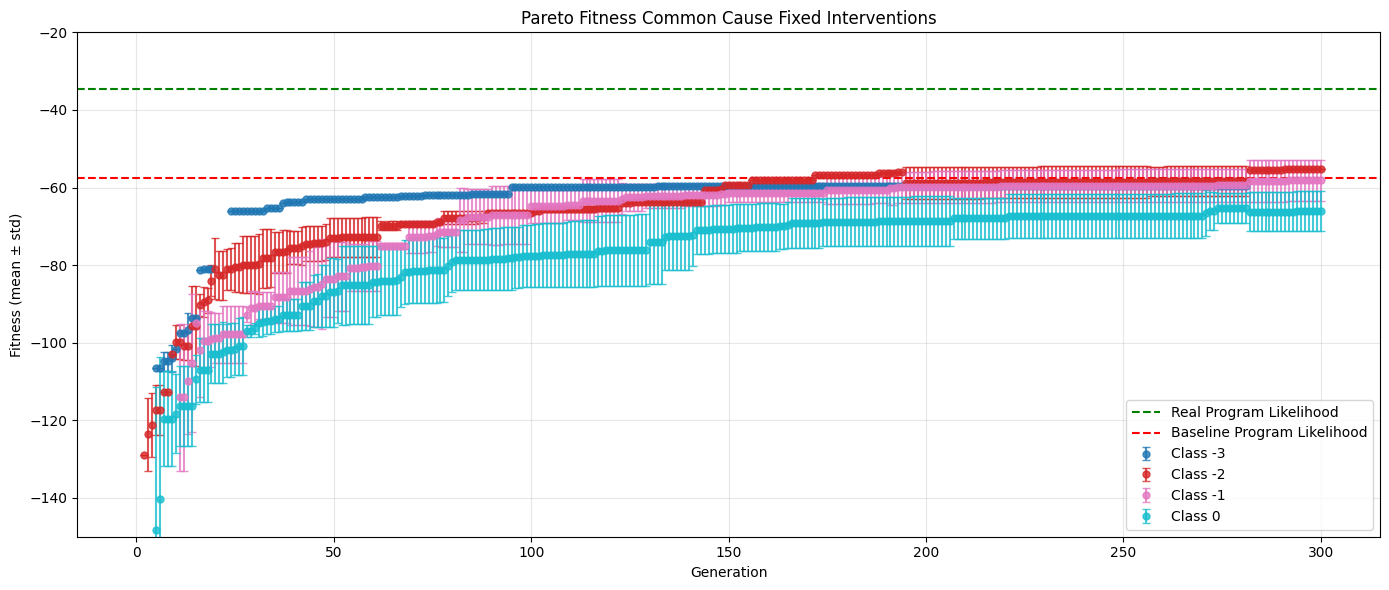

In [28]:
# Plot fitness (mean ± std) vs generation with colors corresponding to class
if pareto_stats.empty:
    print("No data to plot: no pareto_fitness.txt files found.")
else:
    fig, ax = plt.subplots(figsize=(14, 6))

    classes = sorted(pareto_stats['class'].unique())
    colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))
    color_map = {cls: colors[i] for i, cls in enumerate(classes)}

    for cls in classes:
        cls_df = pareto_stats[pareto_stats['class'] == cls]
        ax.errorbar(
            cls_df['generation'],
            cls_df['fitness_mean'],
            yerr=cls_df['fitness_std'],
            fmt='o',
            label=f'Class {cls}',
            alpha=0.8,
            markersize=5,
            color=color_map[cls],
            capsize=3,
            linestyle='None',
        )

    ax.set_xlabel('Generation')
    ax.set_ylabel('Fitness (mean ± std)')
    ax.set_title(f'Pareto Fitness {ex_name.replace("_", " ").title()}')
    ax.legend(title='Class')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-150, -20])
    #add horizontal line for likelihood of real program
    ax.axhline(y=likelihood, color='g', linestyle='--', label='Real Program Likelihood')
    ax.axhline(y=likelihood_base, color='r', linestyle='--', label='Baseline Program Likelihood')
    ax.legend()
    plt.tight_layout()
    plt.show()

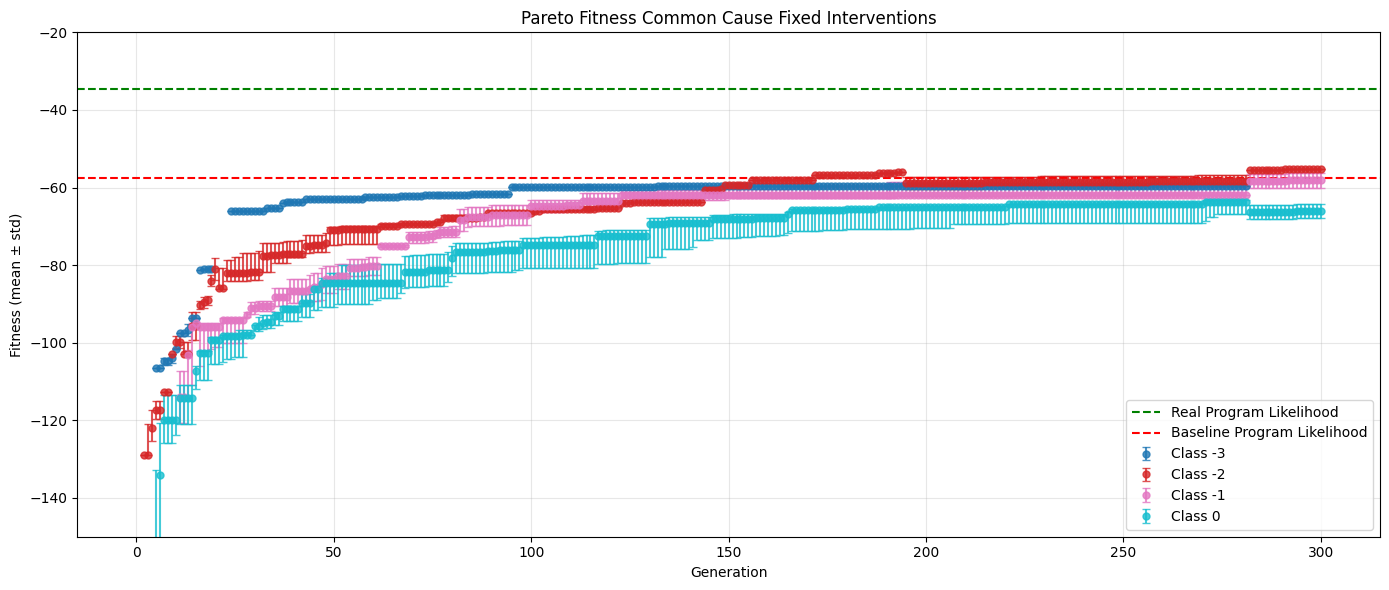

In [29]:
# Plot fitness (mean ± std) vs generation with colors corresponding to class
if pareto_stats.empty:
    print("No data to plot: no pareto_fitness.txt files found.")
else:
    fig, ax = plt.subplots(figsize=(14, 6))

    classes = sorted(pareto_stats['class'].unique())
    colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))
    color_map = {cls: colors[i] for i, cls in enumerate(classes)}

    for cls in classes:
        cls_df = pareto_stats[pareto_stats['class'] == cls]
        ax.errorbar(
            cls_df['generation'],
            cls_df['fitness_median'],
            yerr= [cls_df['fitness_median'] - cls_df['fitness_q1'], cls_df['fitness_q3'] - cls_df['fitness_median']],
            fmt='o',
            label=f'Class {cls}',
            alpha=0.8,
            markersize=5,
            color=color_map[cls],
            capsize=3,
            linestyle='None',
        )

    ax.set_xlabel('Generation')
    ax.set_ylabel('Fitness (mean ± std)')
    ax.set_title(f'Pareto Fitness {ex_name.replace("_", " ").title()}')
    ax.legend(title='Class')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-150, -20])
    #add horizontal line for likelihood of real program
    ax.axhline(y=likelihood, color='g', linestyle='--', label='Real Program Likelihood')
    ax.axhline(y=likelihood_base, color='r', linestyle='--', label='Baseline Program Likelihood')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [30]:
# using pareto_stats, for each class, generate a file txt with columns: generation, median_fitness, fitness_25perc, fitness_75perc
# separated by spaces, named 'class_' + class + '_fitness_summary'+ '.txt' and saved in ../results/synthesis/program
# with column headers: generation median_fitness fitness_25perc fitness_75perc

for cls in classes:
    cls_df = pareto_stats[pareto_stats['class'] == cls]
    output_fp = path.join('..', 'results', 'synthesis', program, f'class_{cls}_fitness_summary.txt')
    cls_df[['generation', 'fitness_median', 'fitness_q1', 'fitness_q3']].to_csv(
        output_fp,
        sep=' ',
        index=False,
        header=['generation', 'median_fitness', 'fitness_25perc', 'fitness_75perc']
    )



OSError: Cannot save file into a non-existent directory: '../results/synthesis/common_cause'

In [ ]:
# find the folder that contains the best fitnes and in that folder open the folder first_front which contains files like 0.txt, 1.txt... and find the file
# that contains in the last row [best fitness, n] the best fitness and print the content of that file
# ...existing code...
# find the run folder that contains the best fitness, open its first_front/*.txt files,
# check the last non-empty row for [best_fitness, n] and print the matching file content
import math
from glob import glob

if pareto_fitness.empty:
    print("No pareto_fitness data available.")
else:
    best_idx = pareto_fitness['fitness'].idxmax()
    best_fitness = float(pareto_fitness.loc[best_idx, 'fitness'])
    best_runs = pareto_fitness[pareto_fitness['fitness'] == best_fitness]['run'].unique().tolist()
    print(f"Best fitness = {best_fitness}, candidate runs: {best_runs}")

    found = False
    for run in best_runs:
        run_dir = path.join(base_dir, run)
        ff_dirs = glob(path.join(run_dir, "**", "first_front"), recursive=True)
        for ff in ff_dirs:
            txt_files = sorted(glob(path.join(ff, "*.txt")))
            for txt_path in txt_files:
                with open(txt_path, "r") as f:
                    lines = [ln.strip() for ln in f if ln.strip()]
                if not lines:
                    continue
                try:
                    last_row = ast.literal_eval(lines[-1])
                except Exception:
                    continue
                if isinstance(last_row, (list, tuple)) and len(last_row) >= 1:
                    try:
                        val = float(last_row[0])
                    except Exception:
                        continue
                    if math.isclose(val, best_fitness, rel_tol=1e-9, abs_tol=1e-6):
                        print(f"Found matching file: {txt_path}")
                        print("---- file content ----")
                        print("\n".join(lines))
                        print("----------------------")
                        found = True
                        # Save the matching file content to a new file in ../results/synthesis
                        output_file = path.join('..', 'results', 'synthesis', f'{ex_name}_best_first_front.txt')
                        with open(output_file, 'w') as out_f:
                            out_f.write("\n".join(lines))
                        break
            if found:
                break
        if found:
            break

    if not found:
        print("No first_front/*.txt file found whose last row matches the best fitness.")
# ...existing code...

Best fitness = -54.502825127293384, candidate runs: ['babbage.units.it_26_1_20_112447_642093_3056180_0']
Found matching file: ../results/common_cause_fixed_interventions/babbage.units.it_26_1_20_112447_642093_3056180_0/first_front/1.txt
---- file content ----
Generation:
300
Phenotype:
2
V1 = gm([4, 10.3, 2.1]);
V2 = V1;
V2 = V2 + uniform([0, 12.8], 2);
V3 = 17 - 48;
V3 = V3 + uniform([32, 7], 1);
Pre-processed Program
:F = gm([1.000000], [10.3], [2.1]);T = F;T = T;T = T + uniform([0.000000, 12.800000], 2);C = 17;C = C - 48;C = C;C = C + uniform([32.000000, 39.000000], 1);Genotype:
[337, 13, 239, 328, 31, 160, 44, 354, 322, 361, 197, 112, 344, 53, 104, 441, 122, 326, 438, 8, 188, 68, 271, 125, 409, 102, 115, 318, 439, 370, 258, 219, 456, 304, 339, 30, 221, 393, 334, 171, 288, 354, 64, 221, 443, 391, 185, 208, 24, 252, 48, 390, 198, 453, 27, 323, 226]
Tree:
None
Fitness on 5000 data:
-54.53929636935718
Fitness:
[-54.502825127293384, -1]
----------------------


In [ ]:
# find the best file per complexity (n) in the last evolution step across all runs
import os
import re
import ast
from glob import glob

def _extract_gen_num(p: str):
    parts = p.split(os.sep)
    for part in reversed(parts):
        m = re.search(r'(?:gen|generation)[_-]?(\d+)', part, re.IGNORECASE)
        if m:
            return int(m.group(1))
        m = re.fullmatch(r'g(\d+)', part, re.IGNORECASE)
        if m:
            return int(m.group(1))
    return None

def _coerce_num(val):
    try:
        num = float(val)
    except Exception:
        return None
    if abs(num - round(num)) < 1e-9:
        return int(round(num))
    return num

if pareto_fitness.empty:
    print('No pareto_fitness data available.')
else:
    max_gen = pareto_fitness['generation'].max()
    if max_gen is not None:
        max_gen = int(max_gen)

    ff_dirs = glob(path.join(base_dir, '**', 'first_front'), recursive=True)
    if not ff_dirs:
        print('No first_front directory found under base_dir.')
    else:
        if max_gen is not None:
            filtered = [d for d in ff_dirs if _extract_gen_num(d) == max_gen]
        else:
            filtered = []
        if filtered:
            ff_dirs = filtered

        best_by_n = {}
        for ff_dir in ff_dirs:
            txt_files = sorted(glob(path.join(ff_dir, '*.txt')))
            for txt_path in txt_files:
                with open(txt_path, 'r') as f:
                    lines = [ln.strip() for ln in f if ln.strip()]
                if not lines:
                    continue
                try:
                    last_row = ast.literal_eval(lines[-1])
                except Exception:
                    continue
                if isinstance(last_row, (list, tuple)) and len(last_row) >= 2:
                    fitness = _coerce_num(last_row[0])
                    n_val = _coerce_num(last_row[1])
                    if fitness is None or n_val is None:
                        continue
                    current = best_by_n.get(n_val)
                    if current is None or fitness > current['fitness']:
                        best_by_n[n_val] = {
                            'fitness': fitness,
                            'path': txt_path,
                            'lines': lines,
                        }

        if not best_by_n:
            print('No valid first_front/*.txt files found for the last evolution step.')
        else:
            for n_val in sorted(best_by_n.keys()):
                entry = best_by_n[n_val]
                print(f'Best for n={n_val} (fitness={entry["fitness"]}): {entry["path"]}')
                print('---- file content ----')
                print('\n'.join(entry['lines']))
                print('----------------------')

                output_file = path.join('..', 'results', 'synthesis', f'{ex_name}_best_first_front_n_{n_val}.txt')
                with open(output_file, 'w') as out_f:
                    out_f.write('\n'.join(entry['lines']))


Best for n=-2 (fitness=-55.16572503885583): ../results/common_cause_fixed_interventions/frandone_26_1_14_170408_797176_4370_0/first_front/2.txt
---- file content ----
Generation:
300
Phenotype:
4
V1 = gm([27, 5.2, 1.5]);
V2 = V1;
V2 = V2 + uniform([1, 17.6], 2);
V3 = V1;
V3 = V3 + uniform([22, 1], 2) - uniform([14, 7], 1);
Pre-processed Program
:C = gm([1.000000], [5.2], [1.5]);T = C;T = T;T = T + uniform([1.000000, 18.600000], 2);F = C;F = F;F = F + uniform([22.000000, 23.000000], 2);F = F - uniform([14.000000, 21.000000], 1);Genotype:
[164, 123, 432, 158, 395, 2, 162, 262, 432, 231, 437, 464, 172, 331, 154, 202, 128, 336, 352, 168, 217, 208, 475, 109, 129, 358, 345, 68, 446, 4, 194, 338, 164, 496, 90, 17, 124, 53, 497, 474, 22, 64, 432, 289, 489, 301, 173, 173, 269]
Tree:
None
Fitness on 5000 data:
-55.16713326319461
Fitness:
[-55.16572503885583, -2]
----------------------
Best for n=-1 (fitness=-54.502825127293384): ../results/common_cause_fixed_interventions/babbage.units.it_26_1_2